<a href="https://colab.research.google.com/github/vineetsalar88/ResearchPaper2/blob/master/April2026/13aprilResnet18BB.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [2]:
# ======================================================
# 🔹 IMPORTS
# ======================================================
import torch
import torch.nn as nn
import torch.optim as optim
import numpy as np
from torchvision import datasets, transforms, models
from torch.utils.data import DataLoader, Subset
from sklearn.model_selection import StratifiedShuffleSplit

# ======================================================
# 🔹 DEVICE
# ======================================================
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# ======================================================
# 🔹 TRANSFORMS
# ======================================================
train_transform = transforms.Compose([
    transforms.RandomResizedCrop(224),
    transforms.RandomHorizontalFlip(),
    transforms.ColorJitter(0.2, 0.2, 0.2),
    transforms.ToTensor(),
    transforms.Normalize([0.485,0.456,0.406],
                         [0.229,0.224,0.225])
])

val_transform = transforms.Compose([
    transforms.Resize((224,224)),
    transforms.ToTensor(),
    transforms.Normalize([0.485,0.456,0.406],
                         [0.229,0.224,0.225])
])

# ======================================================
# 🔹 LOAD FULL DATASET
# ======================================================
dataset = datasets.ImageFolder(
    root="/content/drive/MyDrive/ResearchData/April26/1AprilreshuffledDataset",  # your train folder
    transform=train_transform
)

print("Total dataset size:", len(dataset))

# ======================================================
# 🔹 STRATIFIED 70:30 SPLIT
# ======================================================
labels = [dataset[i][1] for i in range(len(dataset))]

sss = StratifiedShuffleSplit(
    n_splits=1,
    test_size=0.3,
    random_state=42
)

train_idx, val_idx = next(sss.split(np.zeros(len(labels)), labels))

train_dataset = Subset(dataset, train_idx)
val_dataset = Subset(dataset, val_idx)

# IMPORTANT: set validation transform separately
val_dataset.dataset.transform = val_transform

print("Train size:", len(train_dataset))
print("Validation size:", len(val_dataset))

# ======================================================
# 🔹 DATALOADERS
# ======================================================
train_loader = DataLoader(train_dataset, batch_size=16, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=16, shuffle=False)

import torchvision.models as models
import torch.nn as nn

num_classes = len(dataset.classes)

model = models.resnet18(pretrained=True)

# Freeze backbone
for param in model.parameters():
    param.requires_grad = False

# Replace final fully connected layer
model.fc = nn.Linear(
    model.fc.in_features,
    num_classes
)

model = model.to(device)
# ======================================================
# 🔹 LOSS & OPTIMIZER
# ======================================================
criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(
    model.fc.parameters(),
    lr=1e-3
)
# ======================================================
# 🔹 TRAINING SETTINGS
# ======================================================
epochs = 20
best_val_acc = 0.0
patience = 5
patience_counter = 0

# ======================================================
# 🔹 TRAINING LOOP
# ======================================================
for epoch in range(epochs):

    # -------- TRAIN --------
    model.train()
    train_correct = 0
    train_total = 0

    for images, labels in train_loader:
        images = images.to(device)
        labels = labels.to(device)

        optimizer.zero_grad()
        outputs = model(images)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()

        _, preds = torch.max(outputs, 1)
        train_total += labels.size(0)
        train_correct += (preds == labels).sum().item()

    train_acc = 100.0 * train_correct / train_total

    # -------- VALIDATION --------
    model.eval()
    val_correct = 0
    val_total = 0

    with torch.no_grad():
        for images, labels in val_loader:
            images = images.to(device)
            labels = labels.to(device)

            outputs = model(images)
            _, preds = torch.max(outputs, 1)

            val_total += labels.size(0)
            val_correct += (preds == labels).sum().item()

    val_acc = 100.0 * val_correct / val_total

    print(f"Epoch [{epoch+1}/{epochs}] "
          f"Train Acc: {train_acc:.2f}% | "
          f"Val Acc: {val_acc:.2f}%")

    # -------- EARLY STOPPING --------
    if val_acc > best_val_acc:
        best_val_acc = val_acc
        patience_counter = 0
        torch.save(model.state_dict(), "/content/drive/MyDrive/Models/3marchResnet18.pth")
        print("✅ Best model saved")
    else:
        patience_counter += 1
        print(f"⏳ No improvement ({patience_counter}/{patience})")

    if patience_counter >= patience:
        print("🛑 Early stopping triggered")
        break

print("Training complete")
print("Best validation accuracy:", best_val_acc)

Total dataset size: 1122
Train size: 785
Validation size: 337


/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=ResNet18_Weights.IMAGENET1K_V1`. You can also use `weights=ResNet18_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)


Downloading: "https://download.pytorch.org/models/resnet18-f37072fd.pth" to /root/.cache/torch/hub/checkpoints/resnet18-f37072fd.pth


100%|██████████| 44.7M/44.7M [00:00<00:00, 95.3MB/s]


Epoch [1/20] Train Acc: 41.27% | Val Acc: 51.63%
✅ Best model saved
Epoch [2/20] Train Acc: 57.83% | Val Acc: 56.97%
✅ Best model saved
Epoch [3/20] Train Acc: 63.44% | Val Acc: 59.64%
✅ Best model saved
Epoch [4/20] Train Acc: 66.37% | Val Acc: 64.09%
✅ Best model saved
Epoch [5/20] Train Acc: 66.11% | Val Acc: 60.83%
⏳ No improvement (1/5)
Epoch [6/20] Train Acc: 68.28% | Val Acc: 63.20%
⏳ No improvement (2/5)
Epoch [7/20] Train Acc: 70.83% | Val Acc: 66.47%
✅ Best model saved
Epoch [8/20] Train Acc: 70.96% | Val Acc: 64.99%
⏳ No improvement (1/5)
Epoch [9/20] Train Acc: 72.87% | Val Acc: 65.58%
⏳ No improvement (2/5)
Epoch [10/20] Train Acc: 72.36% | Val Acc: 67.95%
✅ Best model saved
Epoch [11/20] Train Acc: 74.01% | Val Acc: 66.17%
⏳ No improvement (1/5)
Epoch [12/20] Train Acc: 74.78% | Val Acc: 67.95%
⏳ No improvement (2/5)
Epoch [13/20] Train Acc: 75.67% | Val Acc: 66.17%
⏳ No improvement (3/5)
Epoch [14/20] Train Acc: 76.05% | Val Acc: 68.55%
✅ Best model saved
Epoch [15/20] T

In [3]:
model.load_state_dict(torch.load("/content/drive/MyDrive/Models/3marchResnet18.pth"))
model.eval()

ResNet(
  (conv1): Conv2d(3, 64, kernel_size=(7, 7), stride=(2, 2), padding=(3, 3), bias=False)
  (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (relu): ReLU(inplace=True)
  (maxpool): MaxPool2d(kernel_size=3, stride=2, padding=1, dilation=1, ceil_mode=False)
  (layer1): Sequential(
    (0): BasicBlock(
      (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (relu): ReLU(inplace=True)
      (conv2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn2): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    )
    (1): BasicBlock(
      (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (relu): ReLU(inplace=True)
  

In [4]:
data_loader = val_loader

In [5]:
import numpy as np
from sklearn.metrics import confusion_matrix, classification_report

all_preds = []
all_labels = []
all_probs = []

with torch.no_grad():
    for images, labels in data_loader:
        images = images.to(device)
        labels = labels.to(device)

        outputs = model(images)
        probs = torch.softmax(outputs, dim=1)

        _, preds = torch.max(outputs, 1)

        all_preds.extend(preds.cpu().numpy())
        all_labels.extend(labels.cpu().numpy())
        all_probs.extend(probs.cpu().numpy())

all_preds = np.array(all_preds)
all_labels = np.array(all_labels)
all_probs = np.array(all_probs)

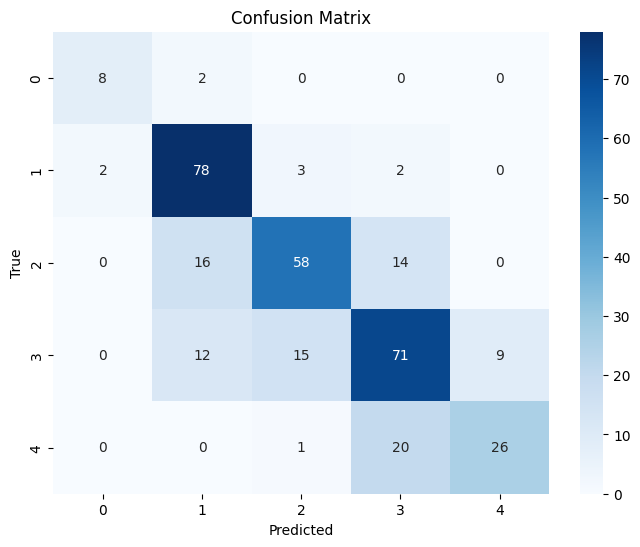

In [6]:
import matplotlib.pyplot as plt
import seaborn as sns

cm = confusion_matrix(all_labels, all_preds)

plt.figure(figsize=(8,6))
sns.heatmap(cm, annot=True, fmt='d',
            xticklabels=dataset.classes,
            yticklabels=dataset.classes,
            cmap="Blues")

plt.xlabel("Predicted")
plt.ylabel("True")
plt.title("Confusion Matrix")
plt.show()

In [7]:
class_acc = cm.diagonal() / cm.sum(axis=1)

for i, acc in enumerate(class_acc):
    print(f"Class {dataset.classes[i]} Accuracy: {acc*100:.2f}%")

Class 0 Accuracy: 80.00%
Class 1 Accuracy: 91.76%
Class 2 Accuracy: 65.91%
Class 3 Accuracy: 66.36%
Class 4 Accuracy: 55.32%


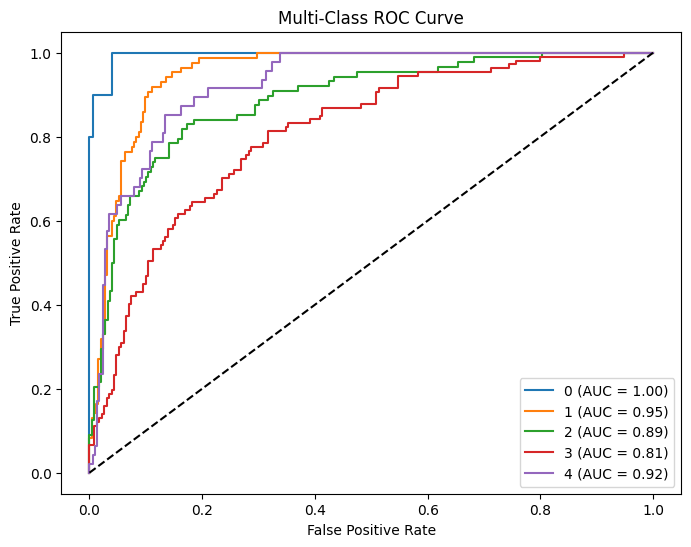

In [9]:
from sklearn.preprocessing import label_binarize
from sklearn.metrics import roc_curve, auc

num_classes = len(dataset.classes)

labels_onehot = label_binarize(all_labels, classes=range(num_classes))

fpr = {}
tpr = {}
roc_auc = {}

for i in range(num_classes):
    fpr[i], tpr[i], _ = roc_curve(labels_onehot[:, i], all_probs[:, i])
    roc_auc[i] = auc(fpr[i], tpr[i])

plt.figure(figsize=(8,6))

for i in range(num_classes):
    plt.plot(fpr[i], tpr[i],
             label=f"{dataset.classes[i]} (AUC = {roc_auc[i]:.2f})")

plt.plot([0,1],[0,1],'k--')
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("Multi-Class ROC Curve")
plt.legend()
plt.show()


In [10]:
print(classification_report(all_labels, all_preds,
                            target_names=dataset.classes))

              precision    recall  f1-score   support

           0       0.80      0.80      0.80        10
           1       0.72      0.92      0.81        85
           2       0.75      0.66      0.70        88
           3       0.66      0.66      0.66       107
           4       0.74      0.55      0.63        47

    accuracy                           0.72       337
   macro avg       0.74      0.72      0.72       337
weighted avg       0.72      0.72      0.71       337



Feature shape: (337, 512)


/usr/local/lib/python3.12/dist-packages/sklearn/manifold/_t_sne.py:1164: FutureWarning: 'n_iter' was renamed to 'max_iter' in version 1.5 and will be removed in 1.7.
  warnings.warn(


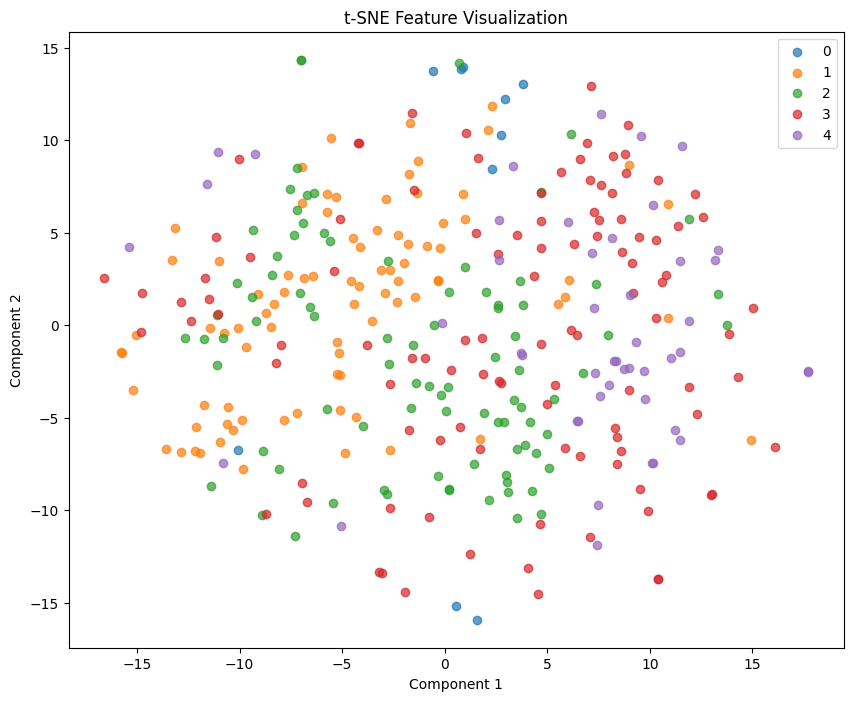

In [11]:
# ======================================================
# 🔹 t-SNE VISUALIZATION (FEATURE SPACE)
# ======================================================
from sklearn.manifold import TSNE

# Extract features instead of logits
feature_extractor = torch.nn.Sequential(*list(model.children())[:-1])  # remove FC layer
feature_extractor = feature_extractor.to(device)
feature_extractor.eval()

features = []
tsne_labels = []

with torch.no_grad():
    for images, labels in val_loader:
        images = images.to(device)

        feats = feature_extractor(images)  # shape: (B, 512, 1, 1)
        feats = feats.view(feats.size(0), -1)  # flatten to (B, 512)

        features.append(feats.cpu().numpy())
        tsne_labels.append(labels.numpy())

# Convert to numpy
features = np.concatenate(features, axis=0)
tsne_labels = np.concatenate(tsne_labels, axis=0)

print("Feature shape:", features.shape)

# ======================================================
# 🔹 APPLY t-SNE
# ======================================================
tsne = TSNE(
    n_components=2,
    perplexity=30,
    learning_rate=200,
    n_iter=1000,
    random_state=42
)

tsne_results = tsne.fit_transform(features)

# ======================================================
# 🔹 PLOT t-SNE
# ======================================================
plt.figure(figsize=(10,8))

for i in range(len(dataset.classes)):
    idx = tsne_labels == i
    plt.scatter(
        tsne_results[idx, 0],
        tsne_results[idx, 1],
        label=dataset.classes[i],
        alpha=0.7
    )

plt.legend()
plt.title("t-SNE Feature Visualization")
plt.xlabel("Component 1")
plt.ylabel("Component 2")
plt.show()